In [1]:
# Project 3 - shipwrecks.
# Admiralty dataset: Wrecks and Obstructions Shapefiles
# This data set contains over 94,000 charted, uncharted, live and dead wrecks and obstructions from around the world. 
# Updated on a quarterly basis. This dataset was last updated Jan 2025.

# Source (https://datahub.admiralty.co.uk/portal/home/item.html?id=4dbf2ace22bf4f9785fb445d0593bc2c)

#You need to run Python 3.10 to run the shapefiles from the Admiralty Database
# %%
import numpy as np
import pandas as pd
import json
import re
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.path import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dateutil import parser
from sklearn.cluster import DBSCAN
from shapely.geometry import Point, Polygon

points = gpd.read_file("Points.shp")
areas = gpd.read_file("Areas.shp")
points_dates = gpd.read_file("same_date_cleaned_points.csv")
points_iso = gpd.read_file("admiralty_iso_dates.csv")



Cleaning up the data set: Coordinates and time notations

In [2]:
# Clean up latitude longtitude coordinates so it has only numbers and no more 'N','E'S'' or 'W'.
points_nav_year = pd.DataFrame(points_iso)

def dms_to_decimal(degrees: float, minutes: float, direction: str) -> float:
    decimal = degrees + minutes / 60
    if direction.upper() in ['S', 'W']:
        decimal = -decimal
    return decimal

def parse_position(pos_str):
    if not isinstance(pos_str, str):
        return None, None
    
    try:
        # Match patterns like: "56 15.161 N,2 32.925 W"
        matches = re.findall(r'(\d+)\s+([\d.]+)\s*([NSEW])', pos_str)
        if len(matches) != 2:
            return None, None
        
        # Latitude
        lat_deg, lat_min, lat_dir = matches[0]
        latitude = dms_to_decimal(float(lat_deg), float(lat_min), lat_dir)

        # Longitude
        lon_deg, lon_min, lon_dir = matches[1]
        longitude = dms_to_decimal(float(lon_deg), float(lon_min), lon_dir)

        return latitude, longitude

    except Exception:
        return None, None

# Apply function to each row
points_nav_year[['latitude', 'longitude']] = points_nav_year['position'].apply(
    lambda x: pd.Series(parse_position(x))
)
#change the year notation to remove deimal 
points_nav_year['year_sunk'] = points_nav_year['year_sunk'].apply(
    lambda x: int(float(str(x))) if isinstance(x, (int, float, str)) and str(x).replace('.', '', 1).isdigit() else x
)

points_nav_year.to_csv("points_nav_year", index = False)
points_nav_year.head(1)


,wreck_id,wreck_cate,obstructio,status,classifica,position,latitude,longitude,horizontal,limits,...,original00,markers,circumstan,surveying_,general_co,last_amend,geometry,date_sunk_iso,year_sunk,unparsed_date
0,2972,dangerous wreck,,dead,,"56 15.161 N,2 32.925 W",56.252683,-2.54875,WGD 2,,...,national coast guard or patrol,,\n \n \n BUILT BY SEEBECK AKT GES. OWNED...,\n H2692/27\n 27.4.27\n SUNK IN APPROX P...,,20160426,MULTIPOINT (-2.5487478 56.252689),1927-04-26,1927,False


In [3]:
# Create csv for timeline of all ships sunk
wrecks_timeline = points_nav_year[['wreck_id', 'longitude', 'latitude', 'year_sunk']]

wrecks_timeline.to_csv("wrecks_timeline", index = False)

# Preview the result
wrecks_timeline.head(1)

,wreck_id,longitude,latitude,year_sunk
0,2972,-2.54875,56.252683,1927


In [4]:
# Group wrecks by year to reduce rows and limit the chance to crash the presentation software
points_nav_year['date_sunk'] = pd.to_datetime(points_nav_year['date_sunk'], errors='coerce')

# Drop rows where the date couldn't be parsed
points_nav_year = points_nav_year.dropna(subset=['date_sunk'])

# Extract the year
points_nav_year['year'] = points_nav_year['date_sunk'].dt.year

# Group by year and count wrecks
wrecks_timeline = points_nav_year.groupby('year').size().reset_index(name='wreck_count')

# Add cumulative wreck count column
wrecks_timeline['total_wrecks'] = wrecks_timeline['wreck_count'].cumsum()


# Optional: Export to CSV (commented out)
wrecks_timeline.to_csv('wrecks_timeline_year_total.csv', index=False)

# Preview the first few rows
wrecks_timeline.head(5)


,year,wreck_count,total_wrecks
0,1684,1,1
1,1687,1,2
2,1690,3,5
3,1691,2,7
4,1703,5,12


In [5]:
# Convert date_sunk to show only the year, so that it can be displayed more easily on a timeline. Including location with longitude and latitude.
points_nav_year['date_sunk'] = pd.to_datetime(points_nav_year['date_sunk'], errors='coerce')

# Drop rows with invalid dates
points_nav_year = points_nav_year.dropna(subset=['date_sunk'])

# Extract year
points_nav_year['year'] = points_nav_year['date_sunk'].dt.year

# Group by year and keep all desired columns
wrecks_timeline = points_nav_year.groupby('year').agg(
    wreck_count=('date_sunk', 'size'),
    avg_latitude=('latitude', 'mean'),
    avg_longitude=('longitude', 'mean')
).reset_index()

# Add cumulative total
wrecks_timeline['total_wrecks'] = wrecks_timeline['wreck_count'].cumsum()

# Export
wrecks_timeline.to_json('wrecks_timeline_per_year.json', orient='records', indent=4)
wrecks_timeline.to_csv('wrecks_timeline_per_year.csv', index=False)

# Preview
wrecks_timeline.head(5)


,year,wreck_count,avg_latitude,avg_longitude,total_wrecks
0,1684,1,50.039483,-5.274350,1
1,1687,1,60.424450,-0.723133,2
2,1690,3,53.073428,-4.428072,5
3,1691,2,50.313300,-4.197408,7
4,1703,5,51.068120,0.815610,12


Create top 5 hotspots of shipwrecks around the world in addition to the Bermuda Triangle

In [ ]:
# Create top 5 Areas with Highest Wreck density & Bermuda Triangle shipwrecks. 

# Step 1: Copy original data to keep points_nav_year unchanged
top_5_areas_bt = points_nav_year.copy()

# Step 2: Prepare coordinates
coords = np.radians(top_5_areas_bt[['latitude', 'longitude']].values)

# Step 3: Run DBSCAN clustering (~10km radius) to set the radius of the top 5 areas
epsilon = 10 / 6371.0088
db = DBSCAN(eps=epsilon, min_samples=5, algorithm='ball_tree', metric='haversine').fit(coords)
top_5_areas_bt['cluster'] = db.labels_

# Step 4: Identify top 5 clusters
top_clusters = top_5_areas_bt[top_5_areas_bt['cluster'] != -1]['cluster'].value_counts().head(5).index

# Step 5: Map top clusters to Area 1–5
area_map = {cluster: f"Area {i+1}" for i, cluster in enumerate(top_clusters)}
top_5_areas_bt['area'] = top_5_areas_bt['cluster'].map(area_map)

# Step 6: Fill all other rows with 'Other Areas'
top_5_areas_bt['area'] = top_5_areas_bt['area'].fillna('Other Areas')

# Step 7: Define Bermuda Triangle coordinates (latitude, longitude)
bermuda_coords = [
    (-80.19, 25.774),  # Miami
    (-66.118, 18.466), # Puerto Rico
    (-64.757, 32.321)  # Bermuda
]

# Function to check if a point is within the Bermuda Triangle
def is_within_bermuda_triangle(lat, lon):
    # Using area-based method for point-in-triangle check
    x1, y1 = bermuda_coords[0]  # Miami
    x2, y2 = bermuda_coords[1]  # Puerto Rico
    x3, y3 = bermuda_coords[2]  # Bermuda

    # Area of the full triangle (determinant formula)
    def area(x1, y1, x2, y2, x3, y3):
        return abs(x1*(y2 - y3) + x2*(y3 - y1) + x3*(y1 - y2)) / 2

    # Area of the sub-triangles formed with the point (px, py)
    def sub_area(px, py, x1, y1, x2, y2, x3, y3):
        return area(px, py, x1, y1, x2, y2) + area(px, py, x2, y2, x3, y3) + area(px, py, x3, y3, x1, y1)

    # Point to check (lat, lon)
    px, py = lon, lat  # Swap latitude and longitude
    total_area = area(x1, y1, x2, y2, x3, y3)

    # Check if the sum of the areas of the sub-triangles equals the area of the full triangle
    return abs(total_area - sub_area(px, py, x1, y1, x2, y2, x3, y3)) < 1e-6  # Precision

# Step 8: Add Bermuda Triangle as a special area
top_5_areas_bt['area'] = top_5_areas_bt.apply(
    lambda row: 'Bermuda Triangle' if is_within_bermuda_triangle(row['latitude'], row['longitude']) else row['area'],
    axis=1
)

# Optional: Display the updated data
top_5_areas_bt['area'].unique()

array(['Area 1', 'Other Areas', 'Area 5', 'Bermuda Triangle', 'Area 3',
       'Area 4', 'Area 2'], dtype=object)

Explore data set further: known/unknown sink causes, valuable cargo,type ship.

In [ ]:
# Find the percentage of rows with data about the circumstance of sinking vs the  without values in the circumstan rows in the data set
# first step, filter out the NaN
points_iso['circumstan_cleaned'] = points_iso['circumstan'].astype(str).str.strip().str.lower().replace('nan', np.nan)

# Step 2: add all the possible variations of no value by guessing the other option
missing_values = ["", "unknown", "not recorded", "?", "n/a", "none", np.nan]

# Total rows
total_rows = len(points_iso)

# Count rows with missing or unclear data
missing_count = points_iso['circumstan_cleaned'].isin(missing_values).sum()

# Count rows with valid/known data
known_count = total_rows - missing_count

# Calculate percentages
missing_pct = (missing_count / total_rows) * 100
known_pct = (known_count / total_rows) * 100
print(f"✅ Known circumstance: {known_pct:.2f}%")
print(f"❌ Missing/unknown circumstance: {missing_pct:.2f}%")

✅ Known circumstance: 21.09%
❌ Missing/unknown circumstance: 78.91%


In [8]:
#create export file for bubble visualization about know and unknown circumstance  (per area)
area_bubble_vis = top_5_areas_bt[['wreck_id','area','latitude', 'longitude','circumstan']]

# Export to CSV
area_bubble_vis.to_csv('area_bubble_vis.csv', index=False)


In [ ]:
# Filter dataset to count the amount of valuable cargo and decide if it is worth creating a filter on the interactive map 
# ore, bauxite, coke, iron ingots, timber,scrap metal, wine,metal,minerals,wood

valuable_cargo = ['ore', 'bauxite', 'coke', 'iron ingots', 'timber', 'scrap metal', 'wine', 'metal', 'minerals', 'wood']
valuable_cargo_counts = points_iso['cargo'].value_counts()
counts_per_cargo = valuable_cargo_counts[valuable_cargo_counts.index.isin(valuable_cargo)]
print(counts_per_cargo)
# Conclusion: Yes, this out put is interesting enough to create special filter on the map to look for wrecks with valuable  cargo create in next cell.

cargo
timber         360
minerals        85
ore             59
coke            45
bauxite         25
scrap metal     17
wine             8
iron ingots      4
Name: count, dtype: int64


In [ ]:
# Define list of valuable cargo so that we can create a filter on the interactive map to show wrecks with valuable cargo.
valuable_cargo = ['ore', 'bauxite', 'coke', 'iron ingots', 'timber',
                  'scrap metal', 'wine', 'metal', 'minerals', 'wood']

# Filter the DataFrame for only those wrecks carrying valuable cargo
valuable_cargo_wrecks = points_iso[points_iso['cargo'].isin(valuable_cargo)][[
    'wreck_id',
    'name', 
    'type',
    'flag',
    'obstructio',
    'latitude',
    'longitude',
    'water_dept',
    'date_sunk',
    'cargo',
    'circumstan'
]]

# Export the result to a JSON file 
valuable_cargo_wrecks.to_json('valuable_cargo_wrecks.json', orient='records', indent=4)

In [ ]:
# Explore different types of ships

# Count wrecks by type
wreck_counts = points_iso['type'].value_counts()

# Rename common and rare groups
wrecks = wreck_counts[wreck_counts >= 100]           # formerly 'common_wrecks'
wrecks_less_than_100 = wreck_counts[wreck_counts < 100]  # formerly 'rare_wrecks'

# Add 'wrecks<10' as a group
wrecks_grouped = wrecks.copy()
wrecks_grouped['wrecks<100'] = wrecks_less_than_100.sum()

# Convert to DataFrame
wreck_summary = wrecks_grouped.reset_index()
wreck_summary.columns = ['Type', 'Count']

# Add total row
total_row = pd.DataFrame([{'Type': 'Total', 'Count': wreck_summary['Count'].sum()}])
wreck_summary = pd.concat([wreck_summary, total_row], ignore_index=True)

wreck_summary.head(45)

,Type,Count
0,,62658
1,steam ship,6634
2,Fisherman's Fastener,4258
3,fishing vessel,4119
4,motor vessel,3504
5,trawler,1877
6,sailing vessel,1639
7,barge,1508
8,carrier,1172
9,Anchor,776


Zooming in on the shipwrecks within the Bermuda Triangle:  
                    - Total wreck count
                    - Amount of vessels and aircraft wrecks
                    - Deepest wreck
                    - Oldest wreck
                    - Wrecks with names only
                    - Known vs Unknown circumstance 

In [ ]:
# Select the data that falls within the coordinates of the Bermuda Triangle.

# Function to convert strings like "56 15.161 N" or "2 32.925 W" to decimal degrees
def to_decimal(coord_str):
    if pd.isna(coord_str) or not isinstance(coord_str, str):
        return None  # Return None for missing or bad values

    try:
        parts = coord_str.split()
        if len(parts) != 3:
            return None  
        degrees = float(parts[0])
        minutes = float(parts[1])
        direction = parts[2].upper()

        decimal = degrees + minutes / 60
        if direction in ['S', 'W']:
            decimal *= -1
        return decimal
    except Exception:
        return None  
    
# Apply conversion to coordinate columns
points_iso['lat_dd'] = points_iso['latitude'].apply(to_decimal)
points_iso['lon_dd'] = points_iso['longitude'].apply(to_decimal)

# Define the Bermuda Triangle (in decimal degrees)
bermuda_coords = [
    (-80.19, 25.774),   # Miami
    (-66.118, 18.466),  # Puerto Rico
    (-64.757, 32.321)   # Bermuda
]

# Use Path to build the triangle
triangle_path = Path(bermuda_coords)

# Apply a mask to flag shipwrecks inside the triangle
points_iso['inside_bermuda_triangle'] = points_iso.apply(
    lambda row: triangle_path.contains_point((row['lon_dd'], row['lat_dd'])), axis=1
)

# Filter results
bermuda_wrecks = points_iso[points_iso['inside_bermuda_triangle']]

# Print result
print(f"✅ Found {len(bermuda_wrecks)} wrecks inside the Bermuda Triangle.")


✅ Found 262 wrecks inside the Bermuda Triangle.


In [13]:
# Exploring the Bermuda Triangle wrecks.
bermuda_wrecks.head(2)


,wreck_id,wreck_cate,obstructio,status,classifica,position,latitude,longitude,horizontal,limits,...,general_co,last_amend,geometry,date_sunk_iso,year_sunk,unparsed_date,circumstan_cleaned,lat_dd,lon_dd,inside_bermuda_triangle
106,85216,non-dangerous wreck,,,,"25 51.921 N,79 20.005 W",25 51.921 N,79 20.005 W,WGD 2,,...,,20160609,MULTIPOINT (-79.33342 25.8653517),,,True,,25.865350,-79.333417,True
1553,53931,dangerous wreck,,,,"25 13 N,78 58 W",25 13 N,78 58 W,WGD 2,,...,,20060224,MULTIPOINT (-78.9666667 25.2166667),,,True,,25.216667,-78.966667,True


In [14]:
#exporting all the wrecks in Bermuda to .json to be used in interactive map.
bermuda_wreck_columns = ['wreck_id', 'date_sunk', 'latitude', 'longitude', 'depth', 'circumstan','cargo']

bermuda_wrecks_details = bermuda_wrecks[bermuda_wreck_columns]
bermuda_wrecks_details.to_json('bermuda_wrecks_details.json', orient='records', indent=4)
print("✅ Exported selected Bermuda wrecks data to 'bermuda_wrecks_details.json'")


✅ Exported selected Bermuda wrecks data to 'bermuda_wrecks_details.json'


In [15]:
# How many aircraft and Vessels in the Bermuda triangle?
# Counts
total_bermuda_wrecks = bermuda_wrecks.shape[0]
bermuda_aircraft = bermuda_wrecks[bermuda_wrecks['type'] == 'aircraft'].shape[0]
# bermuda_helicopter = bermuda_wrecks[bermuda_wrecks['type'] == 'helicopter'].shape[0]
bermuda_vessel = total_bermuda_wrecks - bermuda_aircraft
# Summary table
bermuda_wrecks_vessel_aircraft = pd.DataFrame([{
    'bermuda_wrecks': total_bermuda_wrecks,
    'bermuda_vessels': bermuda_vessel,
    # 'bermuda_helicopters': bermuda_helicopter,
    'bermuda_aircraft': bermuda_aircraft
}])

# bermuda_wrecks_vessel_aircraft.to_csv('bermuda_wrecks_vessel_aircraft', index =  False)
# print(f'bermuda_wrecks_vessel_aircraft is exported to CSV')
print(bermuda_wrecks_vessel_aircraft)

   bermuda_wrecks  bermuda_vessels  bermuda_aircraft
0             262              258                 4


In [16]:
# # Find the deepest wreck inside the triangle

# Apply conversion to coordinates
points_iso['lat_dd'] = points_iso['latitude'].apply(to_decimal)
points_iso['lon_dd'] = points_iso['longitude'].apply(to_decimal)

# Bermuda Triangle vertices (lon, lat)
triangle_path = Path([(-80.19, 25.774), (-66.118, 18.466), (-64.757, 32.321)])

# Mark wrecks inside the Bermuda Triangle
points_iso['inside_bermuda_triangle'] = points_iso.apply(
    lambda row: triangle_path.contains_point((row['lon_dd'], row['lat_dd'])), axis=1
)

# Filter wrecks inside the triangle
bermuda_wrecks = points_iso[points_iso['inside_bermuda_triangle']]

# Find the deepest wreck inside the triangle
deepest = bermuda_wrecks.loc[bermuda_wrecks['depth'].idxmax()]

# Display results
print(f"✅ Deepest Wreck in Bermuda Triangle: {deepest['depth']} meters")
print(f"📍 Location: {deepest['latitude']} / {deepest['longitude']}")
print(f"⚓ Circumstance: {deepest['circumstan']}")
print(f"📅 Date Sunk: {deepest['date_sunk']}")

✅ Deepest Wreck in Bermuda Triangle: 9.8 meters
📍 Location: 32 17.205 N / 64 47.293 W
⚓ Circumstance: 
📅 Date Sunk: 


In [17]:
# Find Oldest wreck in bermuda triangle

# Apply conversion to coordinates
points_iso['lat_dd'] = points_iso['latitude'].apply(to_decimal)
points_iso['lon_dd'] = points_iso['longitude'].apply(to_decimal)

# Define Bermuda Triangle polygon (lon, lat)
triangle_path = Path([(-80.19, 25.774), (-66.118, 18.466), (-64.757, 32.321)])

# Identify wrecks inside the Bermuda Triangle
points_iso['inside_bermuda_triangle'] = points_iso.apply(
    lambda row: triangle_path.contains_point((row['lon_dd'], row['lat_dd'])), axis=1
)

# Filter to shipwrecks inside the triangle
bermuda_wrecks = points_iso[points_iso['inside_bermuda_triangle']].copy()

# Convert 'date_sunk' to datetime
bermuda_wrecks['date_sunk'] = pd.to_datetime(bermuda_wrecks['date_sunk'], errors='coerce')

# Find the oldest wreck (earliest date_sunk)
oldest = bermuda_wrecks.loc[bermuda_wrecks['date_sunk'].idxmin()]

# Display results in a clean table
oldest_wreck = pd.DataFrame([{
    "Label": "Oldest Bermuda Triangle Wreck",
    "Name": oldest['name'],
    "Date Sunk": oldest['date_sunk'],
    "Latitude": oldest['latitude'],
    "Longitude": oldest['longitude'],
    "Circumstance": oldest['circumstan'],
   
}])

print(f"this is the information about the oldest wreck in the dataset {oldest_wreck}")

# Save the filtered DataFrame to a JSON file
output_file = 'oldest_wreck_name.json'
oldest_wreck.to_json(output_file, orient='records', lines=True)

this is the information about the oldest wreck in the dataset                            Label           Name  Date Sunk   Latitude  \
0  Oldest Bermuda Triangle Wreck  HMS CONQUEROR 1861-12-12  23 38.5 N   

  Longitude                                       Circumstance  
0   74 48 W  \n   \n   \n   BUILT IN 1855 BY DEVONPORT DOCK...  


In [18]:
# Filter by wrecks that have a name value 
points_iso[['wreck_id','name']]
#filter out the empty values
non_empty_names = points_iso[points_iso["name"].notna() & (points_iso["name"] != "")]
print(non_empty_names[["name"]])

                    name
0               LINGBANK
3              HUSH WING
5            LARS THOMAS
11      CITY OF BRISBANE
12        HMS INVERCLYDE
...                  ...
100035      HMS COCHRANE
100036         CHICKLADE
100037         BERKSHIRE
100038       SPEKULATION
100039            HECTOR

[28115 rows x 1 columns]


In [ ]:
# Create timeline showing when all ships in dataset sunk & when ships sunk in Bermuda Triangle
# Ensure 'date_sunk' is a datetime column
points_iso['date_sunk'] = pd.to_datetime(points_iso['date_sunk'], errors='coerce')

# Step 1: Filter to Bermuda Triangle wrecks
bermuda_wrecks = points_iso[points_iso['inside_bermuda_triangle']].copy()

# Step 2: Extract years from date_sunk
bermuda_wrecks['year'] = bermuda_wrecks['date_sunk'].dt.year
points_iso['year'] = points_iso['date_sunk'].dt.year

# Step 3: Count number of wrecks per year for both Bermuda and overall
bermuda_counts = bermuda_wrecks.groupby('year').size()
overall_counts = points_iso.groupby('year').size()

# Step 4: Combine into a single DataFrame
all_years = sorted(set(bermuda_counts.index).union(set(overall_counts.index)))
timeline_df = pd.DataFrame(columns=['Area'] + all_years)

# Fill in the rows
bermuda_row = ['Bermuda Triangle Wreck Count'] + [bermuda_counts.get(year, 0) for year in all_years]
overall_row = ['All Wrecks'] + [overall_counts.get(year, 0) for year in all_years]

timeline_df.loc[0] = bermuda_row
timeline_df.loc[1] = overall_row

# Save to CSV
timeline_df.to_csv('wrecks_timeline.csv', index=False)

# print("✅ Timeline CSV 'wrecks_timeline.csv' has been created successfully.")
timeline_df.head(5)

,Area,1684.0,1687.0,1690.0,1691.0,1703.0,1706.0,1707.0,1711.0,1712.0,...,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0
0,Bermuda Triangle Wreck Count,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,All Wrecks,1,1,3,2,5,1,4,1,1,...,18,15,16,19,23,18,8,25,11,23


In [ ]:
# Known and Unknown sunk cause in percentage within the bermuda triangle
bermuda_wrecks.loc[:, 'circumstan_cleaned'] = (
    bermuda_wrecks['circumstan']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace('nan', np.nan)
)

# Define what counts as missing/unknown cause
missing_values = ["", "unknown", "not recorded", "?", "n/a", "none", np.nan]

# Count totals
total_bermuda = len(bermuda_wrecks)
missing_bermuda = bermuda_wrecks['circumstan_cleaned'].isin(missing_values).sum()
known_bermuda = total_bermuda - missing_bermuda

# Create a summary df
bermuda_cause_summary = pd.DataFrame({
    'Cause Status': ['Known', 'Unknown', 'Total'],
    'Count': [known_bermuda, missing_bermuda, total_bermuda],
    'Percentage': [
        round((known_bermuda / total_bermuda) * 100, 2),
        round((missing_bermuda / total_bermuda) * 100, 2),
        100.0
    ]
})

print(bermuda_cause_summary)

  Cause Status  Count  Percentage
0        Known     47       17.94
1      Unknown    215       82.06
2        Total    262      100.00


In [ ]:
# What is the date of the first recorded wreck that included information on the circumstance of sinking?

# Step 1: Filter only known circumstances
valid_data = points_iso[~points_iso['circumstan_cleaned'].isin(missing_values)].copy()

# Step 2: Convert date_sunk to datetime 
valid_data['date_sunk'] = pd.to_datetime(valid_data['date_sunk'], errors='coerce')

# Step 3: Drop rows with invalid/missing dates
valid_data = valid_data.dropna(subset=['date_sunk'])

# Step 4: Find the earliest date
earliest_date = valid_data['date_sunk'].min()

print(f"🕰️ Earliest shipwreck with known circumstance: {earliest_date.date()}")


🕰️ Earliest shipwreck with known circumstance: 1684-04-04


In [22]:
# show relevant columns for graphs and plots on the earliest wreck with known circumstance  wreck
row = valid_data[valid_data['date_sunk'] == earliest_date][[
    'wreck_id', 'flag', 'circumstan', 'cargo', 'position', 'depth',
    'type', 'length', 'height', 'width', 'tonnage', 'last_detec', 'date_sunk'
]].iloc[0]

# Reorder: date_sunk first
ordered_row = {'date_sunk': row['date_sunk']}
ordered_row.update({k: v for k, v in row.items() if k != 'date_sunk'})

# Print cleaned output, using "Unknown" for empty values
for k, v in ordered_row.items():
    if k == 'date_sunk' and pd.notna(v):
        v = pd.to_datetime(v).date()
    val_str = str(v).strip() if pd.notna(v) and str(v).strip() else "unknown"
    print(f"{k}:{val_str}")


date_sunk:1684-04-04
wreck_id:17300
flag:GB
circumstan:CAPTURED DUTCH FLY-BOAT USED IN EVACUATION OF TANGIERS. WAS ON PASSAGE TO ENGLAND WHEN SHE RAN ON TO THE ROCKS AT GUNWALLOE DURING A STORM.
cargo:general and mixed goods
position:50 2.369 N,5 16.461 W
depth:unknown
type:unknown
length:unknown
height:unknown
width:unknown
tonnage:unknown
last_detec:2009


In [23]:
# Leaving out all the "Unknown" columns 
row = valid_data[valid_data['date_sunk'] == earliest_date][[
    'date_sunk', 'position', 'flag', 'circumstan', 'cargo', 'wreck_id'
]].iloc[0]

for k, v in row.items():
    if pd.notna(v) and str(v).strip():
        if k == 'date_sunk':
            v = pd.to_datetime(v).date()
        print(f"{k}:{str(v).strip()}")


date_sunk:1684-04-04
position:50 2.369 N,5 16.461 W
flag:GB
circumstan:CAPTURED DUTCH FLY-BOAT USED IN EVACUATION OF TANGIERS. WAS ON PASSAGE TO ENGLAND WHEN SHE RAN ON TO THE ROCKS AT GUNWALLOE DURING A STORM.
cargo:general and mixed goods
wreck_id:17300


In [24]:
# Deepest wreck with known sunk cause in Bermuda Triangle and in overall dataset.
# Step 1: Filter for wrecks with known circumstances 
valid_data_with_known_cause = points_iso[~points_iso['circumstan_cleaned'].isin(missing_values)]

# Step 2: Get the deepest wreck with known cause
deepest_known_cause = valid_data_with_known_cause.loc[valid_data_with_known_cause['depth'].idxmax()]

# Step 3: Get the overall deepest wreck (regardless of cause)
points_iso['depth'] = pd.to_numeric(points_iso['depth'], errors='coerce')
deepest_overall = points_iso.loc[points_iso['depth'].idxmax()]

# Prepare the summary table with additional columns (including Date Sunk)
deepest_known_cause_row = {
    'Label': 'Deepest (Known Cause)',
    'Depth (m)': deepest_known_cause['depth'],
    'Circumstance': deepest_known_cause['circumstan'],
    'Latitude': deepest_known_cause['latitude'],
    'Longitude': deepest_known_cause['longitude'],
    'Date Sunk': deepest_known_cause['date_sunk']  # Add the date_sunk
}

deepest_unknown_row = {
    'Label': 'Deepest (Overall)',
    'Depth (m)': deepest_overall['depth'],
    'Circumstance': deepest_overall['circumstan'],
    'Latitude': deepest_overall['latitude'],
    'Longitude': deepest_overall['longitude'],
    'Date Sunk': deepest_overall['date_sunk']  # Add the date_sunk
}

# Create a DataFrame from these rows
deepest_wrecks = pd.DataFrame([deepest_known_cause_row, deepest_unknown_row])

# Clean up the formatting
deepest_wrecks['Circumstance'] = deepest_wrecks['Circumstance'].str.strip()
deepest_wrecks['Date Sunk'] = pd.to_datetime(deepest_wrecks['Date Sunk'], errors='coerce').dt.date

# Display the summary table
print(deepest_wrecks)
deepest_wrecks.to_csv('deepest_wrecks.csv', index =  False)


                   Label Depth (m)  \
0  Deepest (Known Cause)     99.55   
1      Deepest (Overall)    4513.0   

                                        Circumstance    Latitude   Longitude  \
0  18.2.41\n   EX- DARCOLM. BUILT IN 1935 BY HAMI...  55 6.609 N  5 29.281 W   
1                                                         47 6 N     16 33 W   

    Date Sunk  
0  1941-02-18  
1         NaT  


In [38]:
# Step 1: Clean 'depth' column and convert to numeric
points_iso['depth'] = pd.to_numeric(points_iso['depth'], errors='coerce')

# Step 2: Clean 'circumstan' column
points_iso['circumstan_cleaned'] = (
    points_iso['circumstan']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace('nan', np.nan)
)

# Define what counts as missing/unknown cause
missing_values = ["", "unknown", "not recorded", "?", "n/a", "none", np.nan]

# Step 3: Filter for wrecks with a known cause
known_cause_data = points_iso[~points_iso['circumstan_cleaned'].isin(missing_values)].copy()

# Step 4: Drop rows with missing or invalid depth
known_cause_data = known_cause_data.dropna(subset=['depth'])
all_depth_data = points_iso.dropna(subset=['depth'])

# Step 5: Get the deepest wreck with known cause
deepest_known = known_cause_data.loc[known_cause_data['depth'].idxmax()]

# Step 6: Get the deepest wreck overall
deepest_overall = all_depth_data.loc[all_depth_data['depth'].idxmax()]

# Step 7: Create a summary table with cleaned-up columns
deepest_summary = pd.DataFrame([
    {
        'Label': 'Deepest (Known Cause)',
        'Depth (m)': deepest_known['depth'],
        'Circumstance': deepest_known['circumstan'].strip(),  # Remove extra whitespace/newlines
        'Latitude': f"{deepest_known['latitude'].strip()}",
        'Longitude': f"{deepest_known['longitude'].strip()}"
    },
    {
        'Label': 'Deepest (Overall)',
        'Depth (m)': deepest_overall['depth'],
        'Circumstance': deepest_overall['circumstan'].strip(),  # Remove extra whitespace/newlines
        'Latitude': f"{deepest_overall['latitude'].strip()}",
        'Longitude': f"{deepest_overall['longitude'].strip()}"
    }
])

# Sort the summary table and clean up the 'Circumstan' field
deepest_summary['Circumstance'] = deepest_summary['Circumstance'].apply(lambda x: x.replace('\n', ' ').strip())
deepest_summary = deepest_summary.sort_values(by='Depth (m)', ascending=False)
deepest_wreck = deepest_summary
# Display the cleaned table
print(deepest_summary.to_string(index=False))

deepest_wreck


# Save the filtered DataFrame to a JSON file
output_file = 'deepest_wreck.json'
deepest_wreck.to_json(output_file, orient='records', lines=True)


                Label  Depth (m)                                                                                                                                                          Circumstance   Latitude   Longitude
    Deepest (Overall)     4513.0                                                                                                                                                                           47 6 N     16 33 W
Deepest (Known Cause)     3008.0 SIR ERNEST SHACKLETON'S EXPLORATION SHIP CRUSHED BY ICE AND SANK NEAR ELEPHANT ISLAND, DURING HIS ILL-FATED ATTEMPT TO CROSS THE SOUTH POLE. (SUNDAY TIMES, 12.4.98). 68 44.35 S 52 19.783 W


Define Top 5 area's in the world with the highest amount of shipwreck in a 10 km radius


In [ ]:
# Define what counts as missing/unknown cause in Bermuda Wrecks
missing_values = ["", "unknown", "not recorded", "?", "n/a", "none", np.nan]

# 1. Clean 'circumstan' in Bermuda wrecks
bermuda_wrecks['circumstan_cleaned'] = (
    bermuda_wrecks['circumstan']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(['nan', 'none', 'null'], np.nan)
)

# 2. Bermuda stats
total_bermuda = len(bermuda_wrecks)
missing_bermuda = bermuda_wrecks['circumstan_cleaned'].isin(missing_values).sum()
known_bermuda = total_bermuda - missing_bermuda

summary_data = [{
    'Area': 'Area 0 - Bermuda',
    'Known Causes': known_bermuda,
    'Unknown/Missing Causes': missing_bermuda,
    'Total Wrecks': total_bermuda,
    'Known %': round((known_bermuda / total_bermuda) * 100, 2) if total_bermuda else 0,
    'Unknown %': round((missing_bermuda / total_bermuda) * 100, 2) if total_bermuda else 0
}]

# 3. Use actual wreck dataset for Area 1–5 
filtered_sorted = top_5_areas_bt.copy()  

# 4. Clean circumstan in filtered data
filtered_sorted['circumstan_cleaned'] = (
    filtered_sorted['circumstan']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(['nan', 'none', 'null'], np.nan)
)

# 5. Loop through areas
area_list = [f"Area {i+1}" for i in range(5)]

for area in area_list:
    area_df = filtered_sorted[filtered_sorted['area'] == area]
    total = len(area_df)
    missing = area_df['circumstan_cleaned'].isin(missing_values).sum()
    known = total - missing
    summary_data.append({
        'Area': area,
        'Known Causes': known,
        'Unknown/Missing Causes': missing,
        'Total Wrecks': total,
        'Known %': round((known / total) * 100, 2) if total else 0,
        'Unknown %': round((missing / total) * 100, 2) if total else 0
    })

# 6. Final summary table
cause_summary_df = pd.DataFrame(summary_data)
print(cause_summary_df)


               Area  Known Causes  Unknown/Missing Causes  Total Wrecks  \
0  Area 0 - Bermuda            47                     215           262   
1            Area 1          5439                     512          5951   
2            Area 2           568                      50           618   
3            Area 3           324                      59           383   
4            Area 4           258                       4           262   
5            Area 5           235                      13           248   

   Known %  Unknown %  
0    17.94      82.06  
1    91.40       8.60  
2    91.91       8.09  
3    84.60      15.40  
4    98.47       1.53  
5    94.76       5.24  


In [27]:
# Build a summary table with wreck count, bounding box, and center point
top5_wrecks = []

for area, group in filtered_sorted.groupby('area'):
    wreck_count = group.shape[0]
    
    # Bounding box
    min_lat, max_lat = group['latitude'].min(), group['latitude'].max()
    min_lon, max_lon = group['longitude'].min(), group['longitude'].max()
    
    # Center point (mean)
    center_lat = group['latitude'].mean()
    center_lon = group['longitude'].mean()
    
    top5_wrecks.append({
        'area': area,
        'wreck_count': wreck_count,
        'center_lat': round(center_lat, 6),
        'center_lon': round(center_lon, 6),
        'min_lat': round(min_lat, 6),
        'max_lat': round(max_lat, 6),
        'min_lon': round(min_lon, 6),
        'max_lon': round(max_lon, 6)
    })

# Convert to DataFrame for easy export or viewing
top5_wreck_10 = pd.DataFrame(top5_wrecks).sort_values(by='area')

# Display the table
print(top5_wreck_10.to_string(index=False))

# Optional: save to CSV if needed
#top5_wreck_10.to_csv("top5_wreck_10.csv", index=False)


            area  wreck_count  center_lat  center_lon    min_lat   max_lat     min_lon    max_lon
          Area 1         5951   52.023136   -0.888056  49.448217 58.033350   -6.489450   4.388333
          Area 2          618   53.499693   -3.510954  53.091833 54.150167   -5.289450  -2.910517
          Area 3          383   54.642971   -5.205866  53.825183 55.529133   -6.344067  -4.098000
          Area 4          262   58.798145   -3.012666  58.124667 59.207167   -3.751467  -2.146717
          Area 5          248   51.802760   -5.396584  51.451950 52.263383   -6.414883  -4.528733
Bermuda Triangle           57   24.837820  -73.624884  18.475000 32.271383  -79.221750 -64.769717
     Other Areas        13513   34.143169   16.888160 -76.950000 77.333333 -180.000000 179.983333


In [28]:
# Export top 5 area's as Json
top5_wreck_10.to_json("top5_wreck_10.json", orient="records", indent=2)


In [29]:
# How many ships sunk per year in the total data set?
points_iso['year_sunk'].value_counts()


year_sunk
          78629
1917.0     1448
1940.0     1239
1918.0     1064
1941.0      683
          ...  
1714.0        1
1633.0        1
1792.0        1
1800.0        1
1651.0        1
Name: count, Length: 282, dtype: int64

The cells below is what I used when I first started working on the dataset, using the "points" GeoDataFrame based on the original shapefiles from the Admiralty.                      Later switched to the points_iso dataframe. Keeping points in here to display the progress in the project.

In [ ]:
# Cleaning up the various date notations in points file and exporting it to CSV
# I've used mostly used the points_iso GeoDataFrame, but wanted to clean up the points file as well.
# Function to parse date to ISO format (YYYY-MM-DD)
def parse_to_iso(date_str):
    try:
        parsed_date = parser.parse(str(date_str), fuzzy=True)
        return parsed_date.strftime('%Y-%m-%d')
    except Exception:
        return pd.NaT  # Not a Time

# Function to extract year
def extract_year(date_str):
    try:
        parsed_date = parser.parse(str(date_str), fuzzy=True)
        return parsed_date.year
    except Exception:
        return None

# Apply parsing functions
points['date_sunk_iso'] = points['date_sunk'].apply(parse_to_iso)
points['year_sunk'] = points['date_sunk'].apply(extract_year)
points['unparsed_date'] = points['date_sunk_iso'].isna()

# Export the cleaned dataset
points.to_csv('admiralty_iso_dates.csv', index=False)

print("✅ Done! Cleaned file saved as 'admiralty_iso_dates.csv")


✅ Done! Cleaned file saved as 'admiralty_iso_dates.csv


In [31]:
#What type of wreck are in this dataset?
points["wreck_cate"].value_counts(dropna=True)

wreck_cate
dangerous wreck                                        29744
non-dangerous wreck                                    24338
wreck showing any portion of hull or superstructure    12000
distributed remains of wreck                             961
wreck showing mast/masts                                 610
Name: count, dtype: int64

In [32]:
#Show the different type of "obstructio"
points["obstructio"].value_counts(dropna=True)

obstructio
foul ground      14718
snag/stump         434
foul area          360
diffuser           182
ground tackle       13
Anchor              10
storage tank         1
Pile                 1
Foul ground          1
Foul area            1
Name: count, dtype: int64

In [33]:
# Replace None values with 'Unknown' to clean up the flags
points['flag_clean'] = points['flag'].fillna('Unknown')

# Strip any leading/trailing whitespace from the flags
points['flag_clean'] = points['flag_clean'].str.strip()

# Replace entries starting with '?' (e.g., '?VIETNAMESE') with 'Unknown'
points['flag_clean'] = points['flag_clean'].replace(r'^\?', 'Unknown', regex=True)

# Fix any 'Unknown' entries that were incorrectly combined (e.g., 'UnknownMALAYSIAN')
points['flag_clean'] = points['flag_clean'].replace(r'^Unknown.*', 'Unknown', regex=True)

# Count and percentage
flag_counts = points['flag_clean'].value_counts()
flag_percentages = (flag_counts / len(points)) * 100

# Combine into summary DataFrame, including 'Unknown' as a category
flag_summary = pd.DataFrame({
    'Count': flag_counts,
    'Percentage': flag_percentages.round(2)
}).sort_values(by='Count', ascending=False)

# Show the summary
print(flag_summary)

            Count  Percentage
flag_clean                   
Unknown     79726       79.69
GB           8587        8.58
DE           1097        1.10
FR            981        0.98
NO            951        0.95
...           ...         ...
SINGAPORE       1        0.00
Tanzanian       1        0.00
Malaysia        1        0.00
ST              1        0.00
BEL             1        0.00

[175 rows x 2 columns]


In [34]:
areas["obstructio"].value_counts(dropna=True)

obstructio
foul ground    388
foul area      132
snag/stump      11
diffuser         2
Name: count, dtype: int64

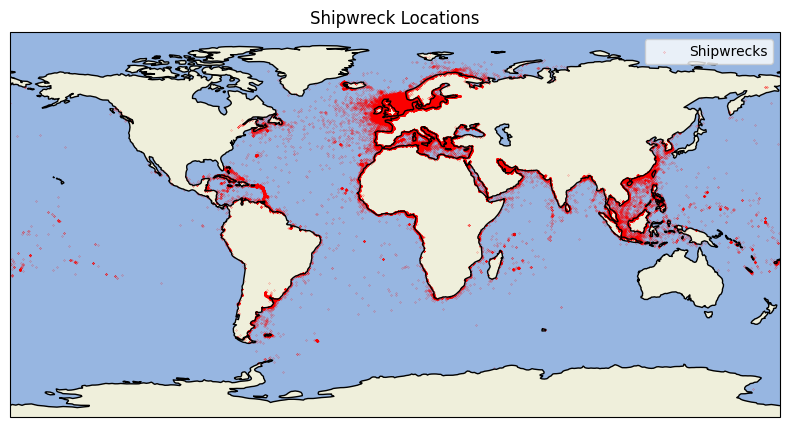

In [ ]:
# Plotting the locations of the wrecks on a map.
# Function to convert DMM (e.g. "2 32.925 W") to decimal degrees
def dmm_to_dd(dmm_str):
    parts = dmm_str.split()
    degrees = float(parts[0])
    minutes = float(parts[1])
    direction = parts[2].upper()

    decimal = degrees + minutes / 60
    if direction in ['S', 'W']:
        decimal *= -1
    return decimal


points = gpd.read_file("Points.shp")

# Convert to decimal degrees
points['lat_dd'] = points['latitude'].apply(dmm_to_dd)
points['lon_dd'] = points['longitude'].apply(dmm_to_dd)

# Plotting with cartopy
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add basic features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot shipwreck points
ax.scatter(points['lon_dd'], points['lat_dd'], color='red', s=.02, label='Shipwrecks')

plt.title('Shipwreck Locations')
plt.legend()
plt.show()

In [36]:
wreck_coordinates = points[['latitude', 'longitude']].to_dict(orient='records')
# wreck_coordinates


In [40]:
# List all flags
# Replace empty strings with a label like 'Unknown'
points['flag_clean'] = points['flag'].replace('', 'Unknown')

# Count and percentage including empty (now labeled as 'Unknown')
flag_counts = points['flag_clean'].value_counts()
flag_percentages = (flag_counts / len(points)) * 100

# Combine into summary DataFrame
flag_summary = pd.DataFrame({
    'Count': flag_counts,
    'Percentage': flag_percentages.round(2)
})

# Optional: sort by count
flag_summary = flag_summary.sort_values(by='Count', ascending=False)
pd.reset_option('display.max_rows')
print(flag_summary)




              Count  Percentage
flag_clean                     
GB             8587        8.58
DE             1097        1.10
FR              981        0.98
NO              951        0.95
PA              825        0.82
...             ...         ...
PY                1        0.00
?BANGLADESHI      1        0.00
Danish            1        0.00
KM                1        0.00
BEL               1        0.00

[188 rows x 2 columns]
